## Setup and Imports

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
print("NLTK data downloaded successfully!")

NLTK data downloaded successfully!


## Data Loading

In [4]:
# Load the Amazon dataset
data_path = 'sentiment labelled sentences/amazon_cells_labelled.txt'
df = pd.read_csv(data_path, sep='\t', header=None, names=['text', 'label'])

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 2)

Label distribution:
label
0    500
1    500
Name: count, dtype: int64

First 5 rows:


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Basic statistics
print(f"\nTotal samples: {len(df)}")
print(f"Positive samples: {(df['label'] == 1).sum()}")
print(f"Negative samples: {(df['label'] == 0).sum()}")

Missing values:
text     0
label    0
dtype: int64

Total samples: 1000
Positive samples: 500
Negative samples: 500


---
# Task 1: Text Preprocessing (30%)

Apply preprocessing steps:
1. Remove punctuation
2. Remove numbers
3. Convert to lowercase
4. Remove stop words
5. Lemmatization

## Select Example Sentences

Choose 3 diverse examples to demonstrate preprocessing steps

In [6]:
# Select 3 example sentences for detailed preprocessing demonstration
example_indices = [0, 50, 100]  # Diverse examples
example_texts = df.iloc[example_indices]['text'].tolist()

print("Original Example Sentences:")
for i, text in enumerate(example_texts, 1):
    print(f"\nExample {i}: {text}")

Original Example Sentences:

Example 1: So there is no way for me to plug it in here in the US unless I go by a converter.

Example 2: Not loud enough and doesn't turn on like it should.

Example 3: Integrated seamlessly with the Motorola RAZR phone.


## Step 1: Remove Punctuation

In [7]:
def remove_punctuation(text):
    """Remove all punctuation from text"""
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply to examples
step1_examples = [remove_punctuation(text) for text in example_texts]

# Display results
print("Step 1: Remove Punctuation\n" + "="*60)
for i in range(len(example_texts)):
    print(f"\nExample {i+1}:")
    print(f"Before: {example_texts[i]}")
    print(f"After:  {step1_examples[i]}")
    
# Apply to entire dataset
df['text_step1'] = df['text'].apply(remove_punctuation)

Step 1: Remove Punctuation

Example 1:
Before: So there is no way for me to plug it in here in the US unless I go by a converter.
After:  So there is no way for me to plug it in here in the US unless I go by a converter

Example 2:
Before: Not loud enough and doesn't turn on like it should.
After:  Not loud enough and doesnt turn on like it should

Example 3:
Before: Integrated seamlessly with the Motorola RAZR phone.
After:  Integrated seamlessly with the Motorola RAZR phone


## Step 2: Remove Numbers

In [8]:
def remove_numbers(text):
    """Remove all numbers from text"""
    return re.sub(r'\d+', '', text)

# Apply to examples
step2_examples = [remove_numbers(text) for text in step1_examples]

# Display results
print("Step 2: Remove Numbers\n" + "="*60)
for i in range(len(step1_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step1_examples[i]}")
    print(f"After:  {step2_examples[i]}")
    
# Apply to entire dataset
df['text_step2'] = df['text_step1'].apply(remove_numbers)

Step 2: Remove Numbers

Example 1:
Before: So there is no way for me to plug it in here in the US unless I go by a converter
After:  So there is no way for me to plug it in here in the US unless I go by a converter

Example 2:
Before: Not loud enough and doesnt turn on like it should
After:  Not loud enough and doesnt turn on like it should

Example 3:
Before: Integrated seamlessly with the Motorola RAZR phone
After:  Integrated seamlessly with the Motorola RAZR phone


## Step 3: Convert to Lowercase

In [9]:
def to_lowercase(text):
    """Convert text to lowercase"""
    return text.lower()

# Apply to examples
step3_examples = [to_lowercase(text) for text in step2_examples]

# Display results
print("Step 3: Convert to Lowercase\n" + "="*60)
for i in range(len(step2_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step2_examples[i]}")
    print(f"After:  {step3_examples[i]}")
    
# Apply to entire dataset
df['text_step3'] = df['text_step2'].apply(to_lowercase)

Step 3: Convert to Lowercase

Example 1:
Before: So there is no way for me to plug it in here in the US unless I go by a converter
After:  so there is no way for me to plug it in here in the us unless i go by a converter

Example 2:
Before: Not loud enough and doesnt turn on like it should
After:  not loud enough and doesnt turn on like it should

Example 3:
Before: Integrated seamlessly with the Motorola RAZR phone
After:  integrated seamlessly with the motorola razr phone


## Step 4: Remove Stop Words

In [10]:
# Get English stop words
stop_words = set(stopwords.words('english'))
print(f"Number of stop words: {len(stop_words)}")
print(f"\nFirst 20 stop words: {list(stop_words)[:20]}")

Number of stop words: 198

First 20 stop words: ["we'll", 'who', 'having', 'again', 'yourselves', 'after', 'did', 'once', "it'll", "wasn't", 'when', 'being', 'doesn', "weren't", 'him', "it'd", 'he', "she's", 'can', 'just']


In [11]:
def remove_stopwords(text):
    """Remove stop words from text"""
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Apply to examples
step4_examples = [remove_stopwords(text) for text in step3_examples]

# Display results
print("Step 4: Remove Stop Words\n" + "="*60)
for i in range(len(step3_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step3_examples[i]}")
    print(f"After:  {step4_examples[i]}")
    # Show removed words
    before_words = set(step3_examples[i].split())
    after_words = set(step4_examples[i].split())
    removed = before_words - after_words
    print(f"Removed: {removed}")
    
# Apply to entire dataset
df['text_step4'] = df['text_step3'].apply(remove_stopwords)

Step 4: Remove Stop Words

Example 1:
Before: so there is no way for me to plug it in here in the us unless i go by a converter
After:  way plug us unless go converter
Removed: {'in', 'here', 'to', 'by', 'me', 'the', 'a', 'is', 'no', 'for', 'there', 'so', 'it', 'i'}

Example 2:
Before: not loud enough and doesnt turn on like it should
After:  loud enough doesnt turn like
Removed: {'should', 'not', 'it', 'and', 'on'}

Example 3:
Before: integrated seamlessly with the motorola razr phone
After:  integrated seamlessly motorola razr phone
Removed: {'the', 'with'}


## Step 5: Lemmatization

In [12]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """Lemmatize all words in text"""
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

# Apply to examples
step5_examples = [lemmatize_text(text) for text in step4_examples]

# Display results
print("Step 5: Lemmatization\n" + "="*60)
for i in range(len(step4_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step4_examples[i]}")
    print(f"After:  {step5_examples[i]}")
    # Show word changes
    before_words = step4_examples[i].split()
    after_words = step5_examples[i].split()
    changes = [(b, a) for b, a in zip(before_words, after_words) if b != a]
    if changes:
        print(f"Changed: {changes}")
    else:
        print("Changed: None")
    
# Apply to entire dataset
df['text_preprocessed'] = df['text_step4'].apply(lemmatize_text)

Step 5: Lemmatization

Example 1:
Before: way plug us unless go converter
After:  way plug u unless go converter
Changed: [('us', 'u')]

Example 2:
Before: loud enough doesnt turn like
After:  loud enough doesnt turn like
Changed: None

Example 3:
Before: integrated seamlessly motorola razr phone
After:  integrated seamlessly motorola razr phone
Changed: None


## Summary: Complete Preprocessing Pipeline

In [13]:
# Create summary table for examples
preprocessing_summary = pd.DataFrame({
    'Step': ['Original', '1. Remove Punctuation', '2. Remove Numbers', 
             '3. Lowercase', '4. Remove Stopwords', '5. Lemmatization'],
    'Example 1': [example_texts[0], step1_examples[0], step2_examples[0], 
                  step3_examples[0], step4_examples[0], step5_examples[0]],
    'Example 2': [example_texts[1], step1_examples[1], step2_examples[1], 
                  step3_examples[1], step4_examples[1], step5_examples[1]],
    'Example 3': [example_texts[2], step1_examples[2], step2_examples[2], 
                  step3_examples[2], step4_examples[2], step5_examples[2]]
})

print("\nPreprocessing Pipeline Summary:")
print("="*100)
preprocessing_summary


Preprocessing Pipeline Summary:


,Step,Example 1,Example 2,Example 3
0,Original,So there is no way for me to plug it in here i...,Not loud enough and doesn't turn on like it sh...,Integrated seamlessly with the Motorola RAZR p...
1,1. Remove Punctuation,So there is no way for me to plug it in here i...,Not loud enough and doesnt turn on like it should,Integrated seamlessly with the Motorola RAZR p...
2,2. Remove Numbers,So there is no way for me to plug it in here i...,Not loud enough and doesnt turn on like it should,Integrated seamlessly with the Motorola RAZR p...
3,3. Lowercase,so there is no way for me to plug it in here i...,not loud enough and doesnt turn on like it should,integrated seamlessly with the motorola razr p...
4,4. Remove Stopwords,way plug us unless go converter,loud enough doesnt turn like,integrated seamlessly motorola razr phone
5,5. Lemmatization,way plug u unless go converter,loud enough doesnt turn like,integrated seamlessly motorola razr phone


In [14]:
# Show statistics of preprocessing impact
print("\nPreprocessing Impact Statistics:")
print("="*60)
print(f"Average word count before: {df['text'].str.split().str.len().mean():.2f}")
print(f"Average word count after: {df['text_preprocessed'].str.split().str.len().mean():.2f}")
print(f"Average reduction: {(1 - df['text_preprocessed'].str.split().str.len().mean() / df['text'].str.split().str.len().mean()) * 100:.2f}%")

# Show first few preprocessed texts
print("\nFirst 5 preprocessed texts:")
for i in range(5):
    print(f"\n{i+1}. Original: {df.iloc[i]['text']}")
    print(f"   Processed: {df.iloc[i]['text_preprocessed']}")


Preprocessing Impact Statistics:
Average word count before: 10.25
Average word count after: 5.28
Average reduction: 48.47%

First 5 preprocessed texts:

1. Original: So there is no way for me to plug it in here in the US unless I go by a converter.
   Processed: way plug u unless go converter

2. Original: Good case, Excellent value.
   Processed: good case excellent value

3. Original: Great for the jawbone.
   Processed: great jawbone

4. Original: Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
   Processed: tied charger conversation lasting minutesmajor problem

5. Original: The mic is great.
   Processed: mic great


---
# Task 2: Bag-of-Words Classification (30%)

Classify sentiment using 3 algorithms:
1. Logistic Regression
2. Naive Bayes (MultinomialNB)
3. Random Forest

## Feature Extraction: TF-IDF

In [15]:
# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=3000, min_df=2, max_df=0.8)
X = tfidf.fit_transform(df['text_preprocessed'])
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nTop 20 features: {tfidf.get_feature_names_out()[:20]}")

Feature matrix shape: (1000, 654)
Number of features: 654
Number of samples: 1000

Top 20 features: ['ability' 'able' 'absolutely' 'accept' 'access' 'actually' 'adapter'
 'additional' 'adorable' 'advertised' 'advise' 'ago' 'allows' 'almost'
 'alone' 'along' 'also' 'although' 'always' 'amazed']


## Train-Test Split

In [16]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set label distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 800
Test set size: 200

Training set label distribution:
label
1    400
0    400
Name: count, dtype: int64

Test set label distribution:
label
1    100
0    100
Name: count, dtype: int64


## Algorithm 1: Logistic Regression

In [17]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"\nLogistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Negative', 'Positive']))

Training Logistic Regression...

Logistic Regression Results:
Accuracy:  0.7750
Precision: 0.7835
Recall:    0.7600
F1-Score:  0.7716

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78       100
    Positive       0.78      0.76      0.77       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200



## Algorithm 2: Naive Bayes

In [18]:
# Train Naive Bayes
print("Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
nb_pred = nb_model.predict(X_test)

# Evaluation
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"\nNaive Bayes Results:")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

Training Naive Bayes...

Naive Bayes Results:
Accuracy:  0.7850
Precision: 0.7522
Recall:    0.8500
F1-Score:  0.7981

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.72      0.77       100
    Positive       0.75      0.85      0.80       100

    accuracy                           0.79       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.79      0.78       200



## Algorithm 3: Random Forest

In [19]:
# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"\nRandom Forest Results:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Negative', 'Positive']))

Training Random Forest...

Random Forest Results:
Accuracy:  0.7200
Precision: 0.7500
Recall:    0.6600
F1-Score:  0.7021

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74       100
    Positive       0.75      0.66      0.70       100

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200



## Comparison of All Algorithms

In [20]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [lr_accuracy, nb_accuracy, rf_accuracy],
    'Precision': [lr_precision, nb_precision, rf_precision],
    'Recall': [lr_recall, nb_recall, rf_recall],
    'F1-Score': [lr_f1, nb_f1, rf_f1]
})

print("\nAlgorithm Comparison:")
print("="*70)
print(comparison_df.to_string(index=False))

# Find best algorithm
best_algo = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Algorithm']
print(f"\nBest performing algorithm (by F1-Score): {best_algo}")


Algorithm Comparison:
          Algorithm  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.775   0.783505    0.76  0.771574
        Naive Bayes     0.785   0.752212    0.85  0.798122
      Random Forest     0.720   0.750000    0.66  0.702128

Best performing algorithm (by F1-Score): Naive Bayes


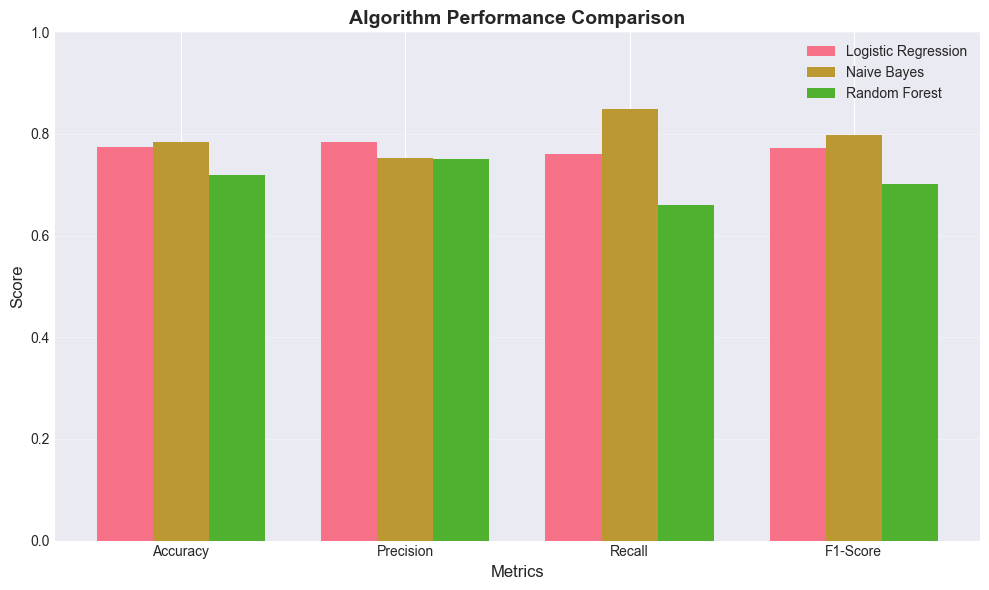

In [21]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

ax.bar(x - width, comparison_df.iloc[0][1:], width, label='Logistic Regression')
ax.bar(x, comparison_df.iloc[1][1:], width, label='Naive Bayes')
ax.bar(x + width, comparison_df.iloc[2][1:], width, label='Random Forest')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Algorithm Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## Confusion Matrices

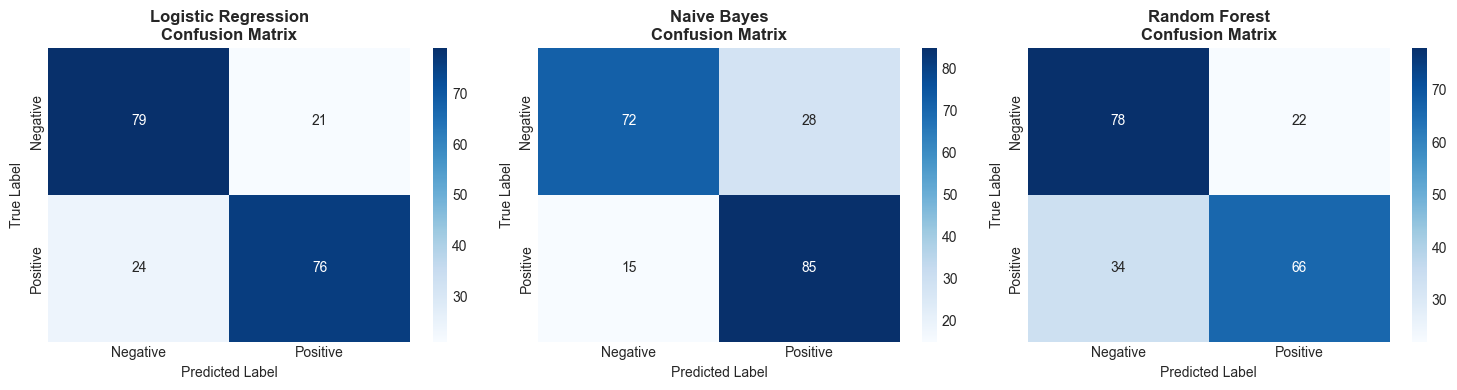

In [22]:
# Create confusion matrices for all three algorithms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

algorithms = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
predictions = [lr_pred, nb_pred, rf_pred]

for idx, (algo, pred, ax) in enumerate(zip(algorithms, predictions, axes)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{algo}\nConfusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [23]:
# Print detailed confusion matrix analysis
for algo, pred in zip(algorithms, predictions):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{algo}:")
    print("="*50)
    print(f"True Negatives:  {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives:  {tp}")
    print(f"Total Correct:   {tn + tp} / {len(y_test)}")
    print(f"Total Incorrect: {fp + fn} / {len(y_test)}")


Logistic Regression:
True Negatives:  79
False Positives: 21
False Negatives: 24
True Positives:  76
Total Correct:   155 / 200
Total Incorrect: 45 / 200

Naive Bayes:
True Negatives:  72
False Positives: 28
False Negatives: 15
True Positives:  85
Total Correct:   157 / 200
Total Incorrect: 43 / 200

Random Forest:
True Negatives:  78
False Positives: 22
False Negatives: 34
True Positives:  66
Total Correct:   144 / 200
Total Incorrect: 56 / 200


## Feature Importance (Random Forest)

Top 20 Most Important Features (Random Forest):
     feature  importance
       great    0.112910
        good    0.059387
   excellent    0.044161
       price    0.040507
        well    0.035092
        nice    0.027942
        love    0.027592
       phone    0.023047
        best    0.022212
        work    0.021996
         buy    0.021088
        easy    0.020968
       first    0.019676
        poor    0.016797
         bad    0.016244
        dont    0.016148
   recommend    0.014804
        case    0.013752
     product    0.012307
disappointed    0.009955


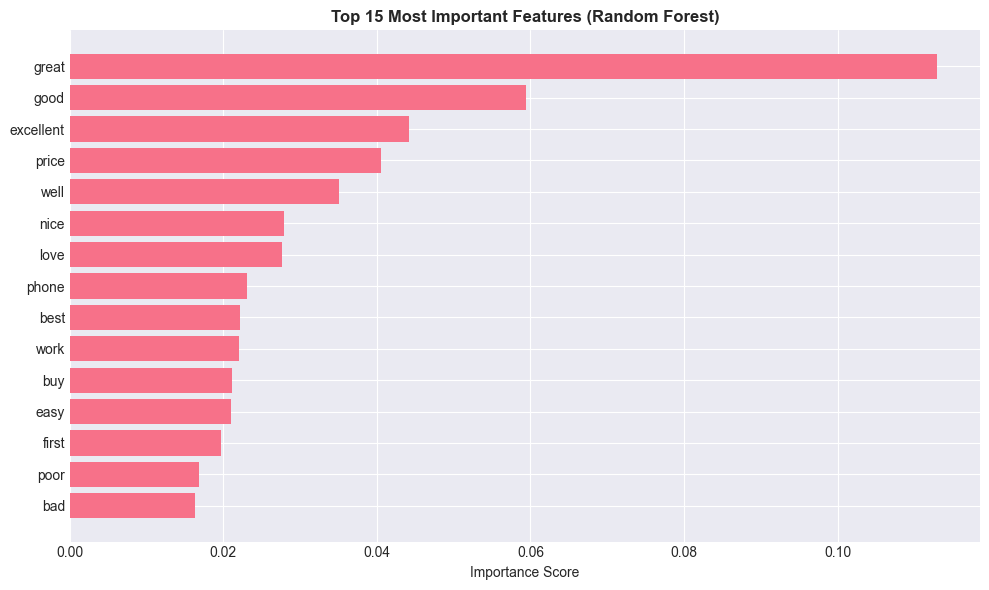

In [24]:
# Get top 20 most important features from Random Forest
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features (Random Forest):")
print("="*50)
print(feature_importance.head(20).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# Save results for Task 2
print("\n" + "="*70)
print("TASK 2 COMPLETE")
print("="*70)
print(f"\nBest Algorithm: {best_algo}")
print(f"Best F1-Score: {comparison_df['F1-Score'].max():.4f}")
print("\nAll algorithms trained and evaluated successfully!")


TASK 2 COMPLETE

Best Algorithm: Naive Bayes
Best F1-Score: 0.7981

All algorithms trained and evaluated successfully!
